In [1]:
from peft import PeftModel
from transformers import AutoModelForSequenceClassification, AutoTokenizer
import torch
import numpy as np
import random
import os
import shap
from collections import defaultdict
from wordcloud import WordCloud
import matplotlib.pyplot as plt

In [2]:
# Set random states.
def set_random_states(random_state):
    # Set various random seeds.
    np.random.seed(random_state)
    random.seed(random_state)
    torch.manual_seed(random_state)
    torch.cuda.manual_seed_all(random_state)
    os.environ["PYTHONHASHSEED"] = str(random_state)
    os.environ["TOKENIZERS_PARALLELISM"] = "false"
    try:
        torch.use_deterministic_algorithms(True)
    except Exception:
        pass
    return random_state
RANDOM_STATE = set_random_states(1618)

# Make constant variables.
MODEL_NAME = "emilyalsentzer/Bio_ClinicalBERT"
PEFT_HEAD = "synth_lora_model_bioclinicalbert"

# Load fine-tuned model.
base_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)

model = PeftModel.from_pretrained(base_model, PEFT_HEAD)

tokenizer = AutoTokenizer.from_pretrained(PEFT_HEAD)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Conside

In [3]:
# Make a prediction function.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

def predict_proba(texts):

    # SHAP sometimes sends numpy arrays
    if isinstance(texts, np.ndarray):
        texts = texts.tolist()

    # ensure list[str]
    texts = [str(t) for t in texts]

    inputs = tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=512,
        return_tensors="pt"
    )

    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.softmax(outputs.logits, dim=1)

    return probs.cpu().numpy()

masker = shap.maskers.Text(tokenizer)
explainer = shap.Explainer(predict_proba, masker, algorithm="partition")
explainer = shap.Explainer(
    predict_proba,
    masker,
    algorithm="partition",
    output_names=["Met Needs", "Unmet Needs"]
)

In [4]:
texts = [
    "Patient denies chest pain but reports fatigue.",
    "Severe abdominal pain with nausea.",
    "No evidence of infection or fever.",
    "Patient reports worsening headache."
]

shap_values = explainer(texts)

In [5]:
token_importance = defaultdict(float)

for doc_idx in range(len(texts)):

    tokens = shap_values.data[doc_idx]
    values = shap_values.values[doc_idx][:,1]  # class 1 contributions

    for token, val in zip(tokens, values):
        token_importance[token] += abs(val)

In [6]:
top_tokens = sorted(
    token_importance.items(),
    key=lambda x: x[1],
    reverse=True
)[:20]

for token, score in top_tokens:
    print(token, score)

Se 0.46210832986980677
headache 0.4152365002373699
worse 0.40176753922423813
ning  0.3233478873880813
abdominal  0.3046330891374964
infection  0.2912114051578101
reports  0.2892909890106239
with  0.2871777078253217
but  0.2408824292360805
pain  0.24061360776249785
denies  0.20824086336506298
fatigue 0.20737634837496444
fever 0.18792901135748252
Pat 0.17293552747287322
chest  0.1593911599557032
or  0.14304981188615784
. 0.12317949845601106
ient  0.10147067114303354
of  0.0748188069628668
nausea 0.05676237813895568


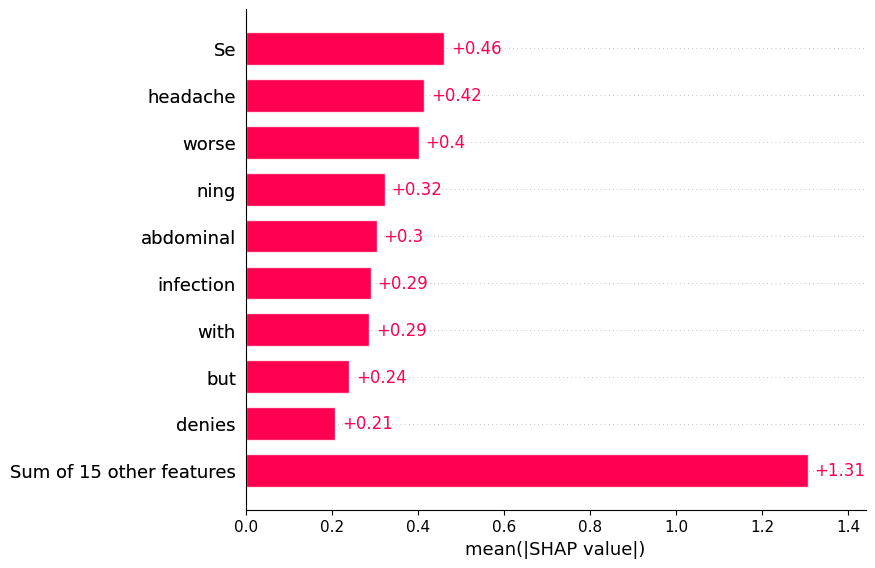

In [7]:
shap.plots.bar(shap_values[:,:,1])

In [8]:
shap.plots.text(shap_values[0,:,1])

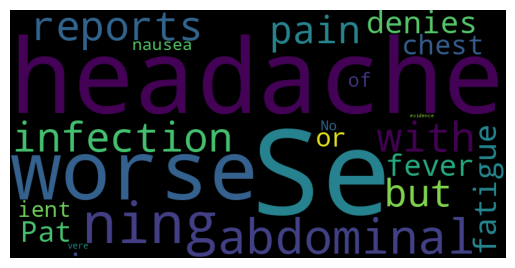

In [9]:
wc = WordCloud(width=800, height=400)

wc.generate_from_frequencies(token_importance)

plt.imshow(wc)
plt.axis("off")
plt.show()